In [1]:
import matplotlib
import numpy as np
import pandas as pd
import pymc3 as pm
import random
import scipy as sp

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
metric_path = "/home/hariprasad-packetai/work/dev/code/ml/mad/results/data/harilaptop-harilocal/harilaptop/system.cpu/system#cpu#total#pct/no_subject/no_subject|system.cpu|system#cpu#total#pct.csv"

# metric_path = "/home/hariprasad-packetai/work/dev/code/ml/mad/results/data/harilaptop-harilocal/cpusatlong/mysql.status/mysql#status#questions/no_subject/no_subject|mysql.status|mysql#status#questions.csv"

anom_thresh = 0.3
val_thresh_ratio = 0.8

sample_size = 25

tol_val = 1e-128

In [3]:
def open_csv(path, root = ""):
    """
    Open a corresponding csv file based on the provided path
    """
    # print(root + path)
    title = path.split("|")[-1].replace(".csv", "")
    df = pd.read_csv(root + path, parse_dates=["datetime"])
    return df

In [4]:
metric_df = open_csv(metric_path)

metric_value = metric_df['value'].values
mad_score = metric_df['anomalyScore'].values

global_size = len(metric_value)

anom_incidents = []

anom_fnd = False
val_thresh = min(metric_value)

for global_cnt in range(global_size):
    cur_value = metric_value[global_cnt]
    cur_score = mad_score[global_cnt]

    if not anom_fnd and cur_score > anom_thresh:
        anom_fnd = True
        val_thresh = val_thresh_ratio*cur_value
        cur_incident = []

    if anom_fnd:
        if cur_score > anom_thresh or cur_value > val_thresh:
            cur_incident.append([cur_value, cur_score])
        else:
            anom_incidents.append(cur_incident)
            anom_fnd = False

    """
    if anom_fnd:
        if cur_score > anom_thresh and cur_value < val_thresh:
            anom_incidents.append(cur_incident)
            anom_fnd = False
        elif cur_score > anom_thresh and cur_value > val_thresh:
            anom_incidents.append(cur_incident)
            val_thresh = val_thresh_ratio*cur_value
            cur_incident = []
        elif 
            cur_incident.append([cur_value, cur_score])
        else:
            anom_incidents.append(cur_incident)
            anom_fnd = False
    """

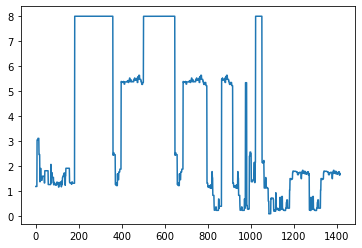

In [5]:
plt.plot(metric_value)
plt.show()

In [6]:
num_incidents = len(anom_incidents)
print(num_incidents)
sample_size = min(sample_size, num_incidents)
global_ind = range(num_incidents)
sample_ind = random.sample(global_ind, sample_size)

if num_incidents == sample_size:
    test_ind = sample_ind
else:
    test_ind = [x for x in global_ind if x not in sample_ind]

5


In [10]:
# Estimation of parameters of probability distributions

dev_val_vec = []
dur_val_vec = []

for cur_ind in sample_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)
    dev_val_vec.append(dev_val)
    dur_val_vec.append(dur_val)

dev_model = pm.Model()
dur_model = pm.Model()
dur_model_exp = pm.Model()
dur_model_nb = pm.Model()

with dev_model:
    lambda_est = pm.Uniform('lambda_est', lower=0, upper=10)
    y_exp = pm.Exponential('y_exp', lam=lambda_est, observed=dev_val_vec)

with dur_model:
    mu_est = pm.Uniform('mu_est', lower=min(dur_val_vec), upper=max(dur_val_vec))
    y_poiss = pm.Poisson('y_poiss', mu=mu_est, observed=dur_val_vec)

with dur_model_exp:
    lambda_dur = pm.Uniform('lambda_dur', lower=0, upper=10)
    y_exp_dur = pm.Exponential('y_exp_dur', lam=lambda_dur, observed=dur_val_vec)

with dur_model_nb:
    mu_nb = pm.Uniform('mu_nb', lower=min(dur_val_vec), upper=max(dur_val_vec))
    alpha_nb = pm.Uniform('alpha_nb', lower=min(dur_val_vec), upper=max(dur_val_vec))
    y_nb_dur = pm.NegativeBinomial('y_nb_dur', mu=mu_nb, alpha=alpha_nb, observed=dur_val_vec)

with dev_model:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    lambda_est_val = np.mean(trace['lambda_est'])

with dur_model:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    mu_est_val = np.mean(trace['mu_est'])

with dur_model_exp:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    lambda_dur_val = np.mean(trace['lambda_dur'])

with dur_model_nb:
    trace = pm.sample(2000, cores=1, chains=2, tune=1000)
    mu_nb_val = np.mean(trace['mu_nb'])
    alpha_nb_val = np.mean(trace['alpha_nb'])

print("Estimated lambda for deviation = {}, estimated mu for duration = {}".format(lambda_est_val, mu_est_val))
print("Estimated lambda for duration = {}".format(lambda_dur_val))
print("Estimated mu for negative binomial = {}, estimated alpha for negative binomial = {}".format(mu_nb_val, alpha_nb_val))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [lambda_est]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 2025.69it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu_est]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 1972.74it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [lambda_dur]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:01<00:00, 2031.19it/s]
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha_nb, mu_nb]
Sampling chain 1, 0 divergences: 100%|██████████| 3000/3000 [00:02<00:00, 1235.08it/s]


Estimated lambda for deviation = 0.20500227640398247, estimated mu for duration = 73.12711727527605
Estimated lambda for duration = 0.016466845611985224
Estimated mu for negative binomial = 76.73327911537109, estimated alpha for negative binomial = 9.470726628145837


In [20]:
print(dev_val_vec)
print(dur_val_vec)
print(np.mean(dur_val_vec))

[2.5401, 8.0, 2.5401, 8.0, 8.0]
[10, 178, 9, 29, 139]
73.0


In [22]:
# mu_est_val = min(1, mu_est_val)

tot_prob_vec = []
rel_score_vec = []

least_prob = 1.0

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)

    print("duration value {} deviation value {}".format(dur_val, dev_val))
    
    dur_prob = max(tol_val, (mu_est_val ** dur_val)*np.exp(-mu_est_val)/sp.special.factorial(dur_val))
    dev_prob = max(tol_val, (lambda_est_val)*np.exp(-dev_val*lambda_est_val))

    with pm.Model():
        y_poiss = pm.Poisson.dist(mu=mu_est_val)
        dur_prob_eval = y_poiss.logp(dur_val).eval()
    
    with pm.Model():
        y_exp = pm.Exponential.dist(lam=lambda_est_val)
        dev_prob_eval = y_exp.logp(dev_val).eval()

    tot_prob = dev_prob*dur_prob

    print("duration prob {} deviation prob {} total prob {}".format(dur_prob, dev_prob, tot_prob))
    print("evaluated duration prob {} deviation probl{}".format(dur_prob_eval, dev_prob_eval))
    
    tot_prob_vec.append(tot_prob)
    
    if tot_prob < least_prob:
        least_prob = tot_prob

for tot_prob in tot_prob_vec:
    rel_score_vec.append(100*(least_prob/tot_prob))
    # rel_score_vec.append(100*(np.log(tot_prob)/np.log(least_prob)))

duration value 10 deviation value 2.5401
duration prob 2.1004773003315053e-20 deviation prob 0.12178957995842002 total prob 2.558162481195701e-21
evaluated duration prob -45.30953771456114 deviation probl-2.1054604777894674
duration value 9 deviation value 2.5401
duration prob 2.8723644232064745e-21 deviation prob 0.12178957995842002 total prob 3.4982405658982593e-22
evaluated duration prob -47.299151372079166 deviation probl-2.1054604777894674
duration value 178 deviation value 8.0
duration prob 1e-128 deviation prob 0.03976562605894327 total prob 3.976562605894327e-130
evaluated duration prob -56.98344696704817 deviation probl-3.2247524067275712
duration value 139 deviation value 8.0
duration prob 2.3185666291896908e-12 deviation prob 0.03976562605894327 total prob 9.219925356910183e-14
evaluated duration prob -26.79004571742894 deviation probl-3.2247524067275712
duration value 29 deviation value 8.0
duration prob 2.254409587432086e-09 deviation prob 0.03976562605894327 total prob 8.

In [36]:
# 

tot_prob_vec = []
rel_score_vec = []

least_prob = 1.0

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)

    print("duration value {} deviation value {}".format(dur_val, dev_val))

    with pm.Model():
        print("mu_nb {} alpha_nb {} dur_val {}".format(mu_nb_val, alpha_nb_val, dur_val))
        y_nb = pm.NegativeBinomial.dist(mu=mu_nb_val, alpha=alpha_nb_val)
        dur_prob = y_nb.logp(dur_val).eval()
    
    with pm.Model():
        y_exp = pm.Exponential.dist(lam=lambda_est_val)
        dev_prob = y_exp.logp(dev_val).eval()

    tot_prob = np.exp(dev_prob + dur_prob)

    print("duration prob {} deviation prob {} total prob {}".format(dur_prob, dev_prob, tot_prob))

    tot_prob_vec.append(tot_prob)

    if tot_prob < least_prob:
        least_prob = tot_prob

for tot_prob in tot_prob_vec:
    rel_score_vec.append(100*(least_prob/tot_prob))
    # rel_score_vec.append(100*(np.log(tot_prob)/np.log(least_prob)))

duration value 10 deviation value 2.5401
mu_nb 76.73327911537109 alpha_nb 9.470726628145837 dur_val 10
duration prob -11.034562353515852 deviation prob -2.1054604777894674 total prob 1.9649911208487e-06
duration value 9 deviation value 2.5401
mu_nb 76.73327911537109 alpha_nb 9.470726628145837 dur_val 9
duration prob -11.531782740250465 deviation prob -2.1054604777894674 total prob 1.1951447884470486e-06
duration value 178 deviation value 8.0
mu_nb 76.73327911537109 alpha_nb 9.470726628145837 dur_val 178
duration prob -9.141994576129125 deviation prob -3.2247524067275712 total prob 4.25784675153115e-06
duration value 139 deviation value 8.0
mu_nb 76.73327911537109 alpha_nb 9.470726628145837 dur_val 139
duration prob -6.637063554971654 deviation prob -3.2247524067275712 total prob 5.2127601944053566e-05
duration value 29 deviation value 8.0
mu_nb 76.73327911537109 alpha_nb 9.470726628145837 dur_val 29
duration prob -6.133702879312352 deviation prob -3.2247524067275712 total prob 8.623320

In [42]:
tot_prob_vec = []
rel_score_vec = []

least_prob = 1.0

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    dev_val = max([x[0] for x in cur_incident])
    dur_val = len(cur_incident)

    print("duration value {} deviation value {}".format(dur_val, dev_val))

    with pm.Model():
        y_dur_exp = pm.Exponential.dist(lam=lambda_dur_val)
        dur_prob = y_dur_exp.logp(dur_val).eval()
    
    with pm.Model():
        y_exp = pm.Exponential.dist(lam=lambda_est_val)
        dev_prob = y_exp.logp(dev_val).eval()

    tot_prob = np.exp(dev_prob + dur_prob)

    print("duration prob {} deviation prob {} total prob {}".format(dur_prob, dev_prob, tot_prob))

    tot_prob_vec.append(tot_prob)

    if tot_prob < least_prob:
        least_prob = tot_prob

for tot_prob in tot_prob_vec:
    rel_score_vec.append(100*(least_prob/tot_prob))

duration value 10 deviation value 2.5401
duration prob -4.27107473251066 deviation prob -2.1054604777894674 total prob 0.0017010063877233468
duration value 9 deviation value 2.5401
duration prob -4.2546078868986745 deviation prob -2.1054604777894674 total prob 0.001729248488282422
duration value 178 deviation value 8.0
duration prob -7.037504795324178 deviation prob -3.2247524067275712 total prob 3.492676203757246e-05
duration value 139 deviation value 8.0
duration prob -6.395297816456754 deviation prob -3.2247524067275712 total prob 6.63842835392451e-05
duration value 29 deviation value 8.0
duration prob -4.583944799138379 deviation prob -3.2247524067275712 total prob 0.0004061868811509695


In [43]:
anom_curves = []
gap_size = 10

filler_gap = [0 for _ in range(gap_size)]

anom_curves.extend(filler_gap)

for cur_ind in test_ind:
    cur_incident = anom_incidents[cur_ind]
    anom_curve = [x[0] for x in cur_incident]
    anom_curves.extend(anom_curve)
    anom_curves.extend(filler_gap)

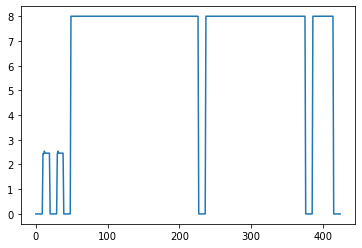

[2.0532998752767164, 2.0197653647951723, 100.0, 52.61299840183473, 8.598692783628099]


In [44]:
plt.plot(anom_curves)
plt.show()
print(rel_score_vec)

In [57]:
mu_test = 19.92
lambda_test = 0.2049

dur_val = 20
dev_val = 8

tol_val = 1e-128

dur_prob = max(tol_val, (mu_test ** dur_val)*np.exp(-mu_test)/sp.special.factorial(dur_val))
dev_prob = max(tol_val, (lambda_test)*np.exp(-dev_val*lambda_test))

print("Duration probability {}, deviation probability {}".format(dur_prob, dev_prob))

Duration probability 0.08882106686728124, deviation probability 0.039778320596211864


In [29]:
y_nb = pm.NegativeBinomial.dist(mu=76, alpha=9)
op_prob = y_nb.logp(70).eval()

print(op_prob)

-4.165088488553629
